### Partie 1 – Analyse exploratoire
---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

# Configuration matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
np.random.seed(42)

In [9]:
# Chargement des données
df = pd.read_csv('Mall_Customers.csv')

# Structure du dataset
print("=== APERÇU DU DATASET ===")
print(f"Shape : {df.shape}")
print(f"Colonnes : {df.columns.tolist()}")
print(f"Types :\n{df.dtypes}")
print(f"\nValeurs manquantes :\n{df.isnull().sum()}")
print(f"\nDoublons : {df.duplicated().sum()}")

# Aperçu des données
df.head()

=== APERÇU DU DATASET ===
Shape : (200, 5)
Colonnes : ['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Types :
CustomerID                 int64
Genre                     object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

Valeurs manquantes :
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Doublons : 0


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


donc on a bien 200 ***lignes non null*** donc ***0 valeurs manquantes*** et 5 ***colonnes***

### 2. Identifier les variables pertinentes pour la segmentation.

***CustomerID*** n'est ***pas pertinent***, nous allons ***l'ignorer***

donc nous gardons: ***Genre*** - ***Age*** - ***Annual Income*** - ***Spending Score***

### 3. Analyser la distribution des variables numériques.

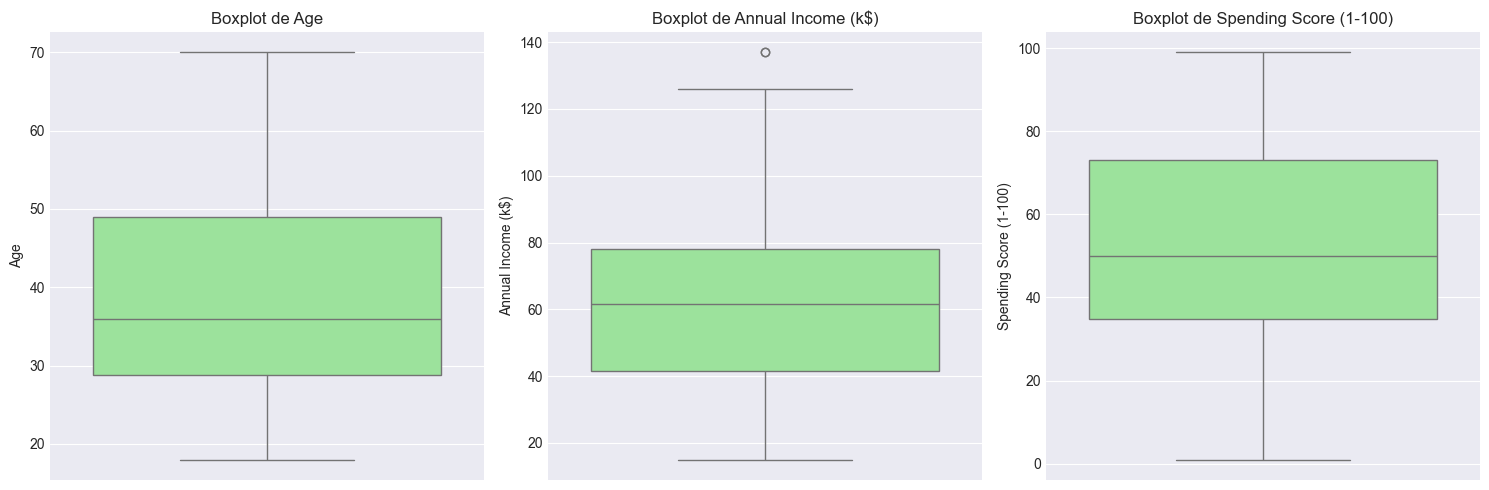

In [6]:
# Liste des variables à examiner
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

# Création des boxplots
plt.figure(figsize=(15, 5))
for i, col in enumerate(features):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'Boxplot de {col}')

plt.tight_layout()
plt.show()

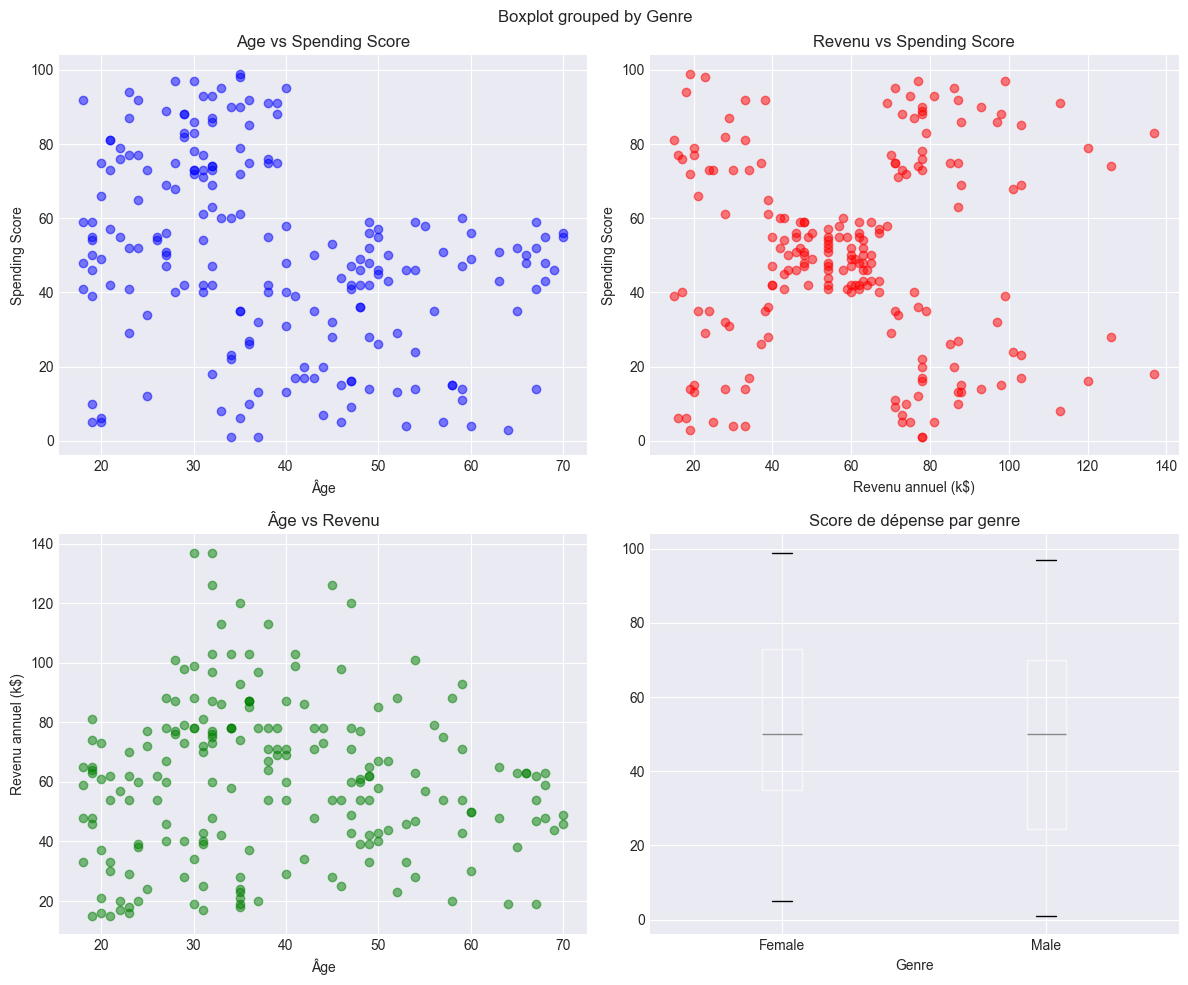

In [12]:
# Comparons différentes combinaisons de variables
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Combinaison 1 : Age vs Spending Score (ton choix)
axes[0,0].scatter(df['Age'], df['Spending Score (1-100)'], alpha=0.5, color='blue')
axes[0,0].set_xlabel('Âge')
axes[0,0].set_ylabel('Spending Score')
axes[0,0].set_title('Age vs Spending Score')

# Combinaison 2 : Income vs Spending Score
axes[0,1].scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], alpha=0.5, color='red')
axes[0,1].set_xlabel('Revenu annuel (k$)')
axes[0,1].set_ylabel('Spending Score')
axes[0,1].set_title('Revenu vs Spending Score')

# Combinaison 3 : Age vs Income
axes[1,0].scatter(df['Age'], df['Annual Income (k$)'], alpha=0.5, color='green')
axes[1,0].set_xlabel('Âge')
axes[1,0].set_ylabel('Revenu annuel (k$)')
axes[1,0].set_title('Âge vs Revenu')

# Combinaison 4 : Distribution par genre (boîte à moustaches)
df.boxplot(column='Spending Score (1-100)', by='Genre', ax=axes[1,1])
axes[1,1].set_title('Score de dépense par genre')
axes[1,1].set_xlabel('Genre')

plt.tight_layout()
plt.show()

Pour le point 1.5 (Justifier les variables retenues) :
Si on veut une segmentation qui aide le marketing à comprendre "qui a de l'argent et qui dépense", les variables Annual Income et Spending Score sont les plus discriminantes (elles séparent mieux les clients que l'âge, par exemple).

In [13]:
# 1. Sélection des variables
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# 2. Initialisation du scaler
scaler = StandardScaler()

# 3. Application de la transformation
X_scaled = scaler.fit_transform(X)

print("Premières lignes après standardisation :\n", X_scaled[:5])

Premières lignes après standardisation :
 [[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


Nombre de clusters (k) = 1 | Inertie = 400.00
Nombre de clusters (k) = 2 | Inertie = 273.67
Nombre de clusters (k) = 3 | Inertie = 157.70
Nombre de clusters (k) = 4 | Inertie = 109.23
Nombre de clusters (k) = 5 | Inertie = 65.57
Nombre de clusters (k) = 6 | Inertie = 60.13
Nombre de clusters (k) = 7 | Inertie = 49.67
Nombre de clusters (k) = 8 | Inertie = 37.32
Nombre de clusters (k) = 9 | Inertie = 32.50
Nombre de clusters (k) = 10 | Inertie = 30.06


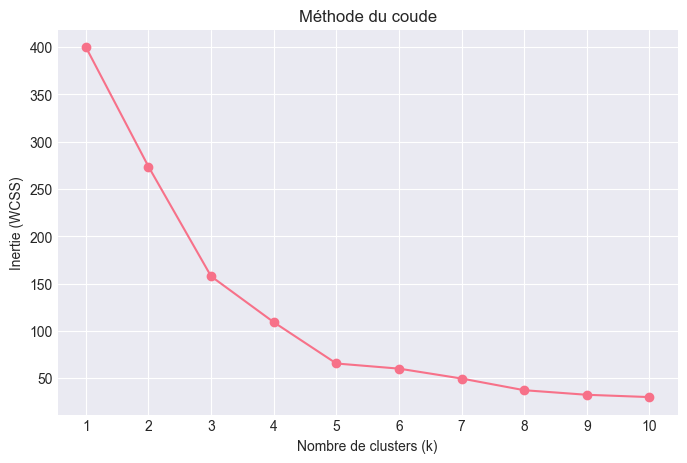

In [18]:
import matplotlib.pyplot as plt

wcss = [] 

for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(X_scaled)
    
    # On récupère l'inertie
    inertie_actuelle = kmeans.inertia_
    wcss.append(inertie_actuelle)
    
    # ON AFFICHE LE RÉSULTAT ICI
    print(f"Nombre de clusters (k) = {i} | Inertie = {inertie_actuelle:.2f}")


plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Méthode du coude")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie (WCSS)")
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [16]:
# On crée le modèle final avec 5 clusters
kmeans_final = KMeans(n_clusters=5, init='k-means++', random_state=42)

# On entraîne et on prédit en même temps
y_kmeans = kmeans_final.fit_predict(X_scaled)

# On ajoute ces étiquettes à notre tableau d'origine pour l'analyse
df['Cluster'] = y_kmeans

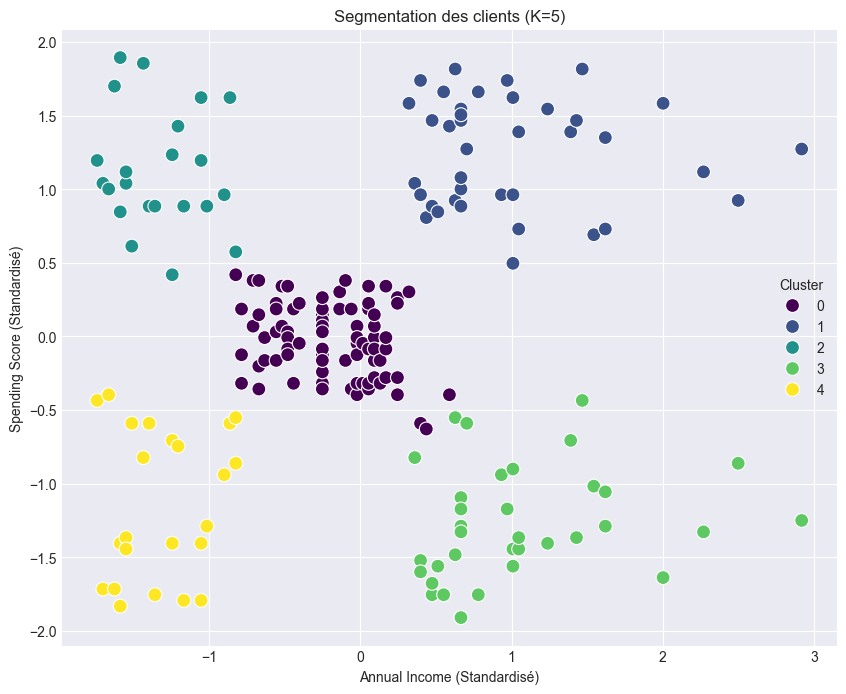

In [17]:
# Partie 5 : Visualisation des clusters
plt.figure(figsize=(10, 8))

# On trace les points en les colorant par cluster
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=df['Cluster'], palette='viridis', s=100)

plt.title('Segmentation des clients (K=5)')
plt.xlabel('Annual Income (Standardisé)')
plt.ylabel('Spending Score (Standardisé)')
plt.legend(title='Cluster')
plt.show()